# CAP417 – Part C – Hands-on 01
## Brownian Motion: AI Agent Benchmark Comparison

| | |
|---|---|
| **Course** | CAP417 – Computational Statistics |
| **Student** | Rian Koja |
| **Submission** | Google Colab – shared with reinaldo.rosa@inpe.br |

---

## Objective

This notebook compares the implementations and results produced by two AI agents — **Claude Code** and **Antigravity** — for the same task:

1. Generate Brownian motion time series (N = 100, 1 000, 10 000)
2. Visualise each series via a histogram and discuss the shape
3. Compute the first four statistical moments (mean, variance, skewness, kurtosis)
4. Benchmark: compare the two agents' results and discuss differences

All data artifacts (`.parquet` files, `.svg` histograms, `.md` discussions) were generated by the agents and are **loaded here without modification**, as required by the assignment. Gemini CLI was intended for the task, but due to systme issues, Antigravity was used instead of it. Claude Code was used with Sonnet 4.6 and Antigravity with Gemini Flash 3. While Flash 3's performance an capabilities are notably limited ocmpared so Sonnet 4.6, both agents are well suited for a task of this size and complexity.

## 0. Environment Setup

The cell below installs required libraries (if needed) and sets up the file paths.

> **Google Colab users**: upload the `claude-code/` and `gemini-cli/` folders to `/content/` before running, or mount Google Drive and adjust `BASE` accordingly.

In [6]:
import subprocess, sys, os
from pathlib import Path


# ---- Path resolution ------------------------------------------------
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Option A: mount Google Drive
    # from google.colab import drive
    # drive.mount('/content/drive')
    # BASE = Path('/content/drive/MyDrive/hands_on_01')

    # Option B: files uploaded directly to /content
    BASE = Path('/content')
    print('Running in Colab – make sure claude-code/ and gemini-cli/ are uploaded.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'numpy', 'pandas', 'scipy', 'matplotlib', 'pyarrow'])
else:
    BASE = Path('.').resolve()

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from IPython.display import Markdown, display


CLAUDE_DIR = BASE / 'claude-code'
GEMINI_DIR = BASE / 'gemini-cli'
N_VALUES   = [100, 1000, 10000]

print(f'Base path : {BASE}')
print(f'Claude dir: {CLAUDE_DIR}')
print(f'Gemini dir: {GEMINI_DIR}')

Base path : C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_01
Claude dir: C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_01\claude-code
Gemini dir: C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_01\gemini-cli


---
## 1. Agent Implementations — Algorithm Comparison

Before loading results, we summarise the key choices made by each agent.

| Aspect | Claude Code (`generate.py`) | Gemini CLI (`hands_on_01.py`) |
|--------|----------------------------|--------------------------------|
| Random seed | `np.random.default_rng(seed=42)` — **fixed** | `np.random.normal(...)` — **no seed** |
| Noise generation | `rng.standard_normal(n)` | `np.random.normal(0, 1, n)` |
| Brownian series | `np.cumsum(noise)` | `np.cumsum(noise)` |
| Variance estimator | `np.var(series, ddof=1)` — sample (unbiased) | `np.var(series)` — population (biased) |
| Histogram y-axis | Density (`density=True`) + normal fit overlay | Frequency (raw counts) |
| Moments output | Wide table (1 row per N) | Long table (1 row per moment) |
| Kurtosis | Fisher (K=0) **and** Pearson (K=3) | Fisher (K=0) **and** Pearson (K=3) |

**Critical difference**: `ddof=1` vs `ddof=0` in variance. The ratio is exactly $N/(N-1)$ (Bessel's correction).

In [7]:
# Load all agent artifacts

def load_claude_moments(n):
    df = pd.read_parquet(CLAUDE_DIR / f'moments_{n}.parquet')
    r = df.iloc[0]
    return {k: float(r[k]) for k in
            ['mean', 'variance', 'skewness', 'kurtosis_fisher', 'kurtosis_pearson']}

def load_gemini_moments(n):
    df = pd.read_parquet(GEMINI_DIR / f'moments_{n}.parquet').set_index('moment')['value']
    return {k: float(df[k]) for k in
            ['mean', 'variance', 'skewness', 'kurtosis_fisher', 'kurtosis_pearson']}

claude_ts  = {n: pd.read_parquet(CLAUDE_DIR / f'tseries_{n}.parquet')  for n in N_VALUES}
gemini_ts  = {n: pd.read_parquet(GEMINI_DIR / f'tseries_{n}.parquet')  for n in N_VALUES}
claude_mom = {n: load_claude_moments(n) for n in N_VALUES}
gemini_mom = {n: load_gemini_moments(n) for n in N_VALUES}

print('All artifacts loaded.')
print(f"  Claude tseries columns: {list(claude_ts[100].columns)}")
print(f"  Gemini tseries columns: {list(gemini_ts[100].columns)}")

All artifacts loaded.
  Claude tseries columns: ['time_step', 'value']
  Gemini tseries columns: ['index', 'value']


---
## Part 1 — Time Series

Both agents generated Brownian motion as the cumulative sum of Gaussian increments.
The paths differ because Claude used a fixed seed and Gemini did not.

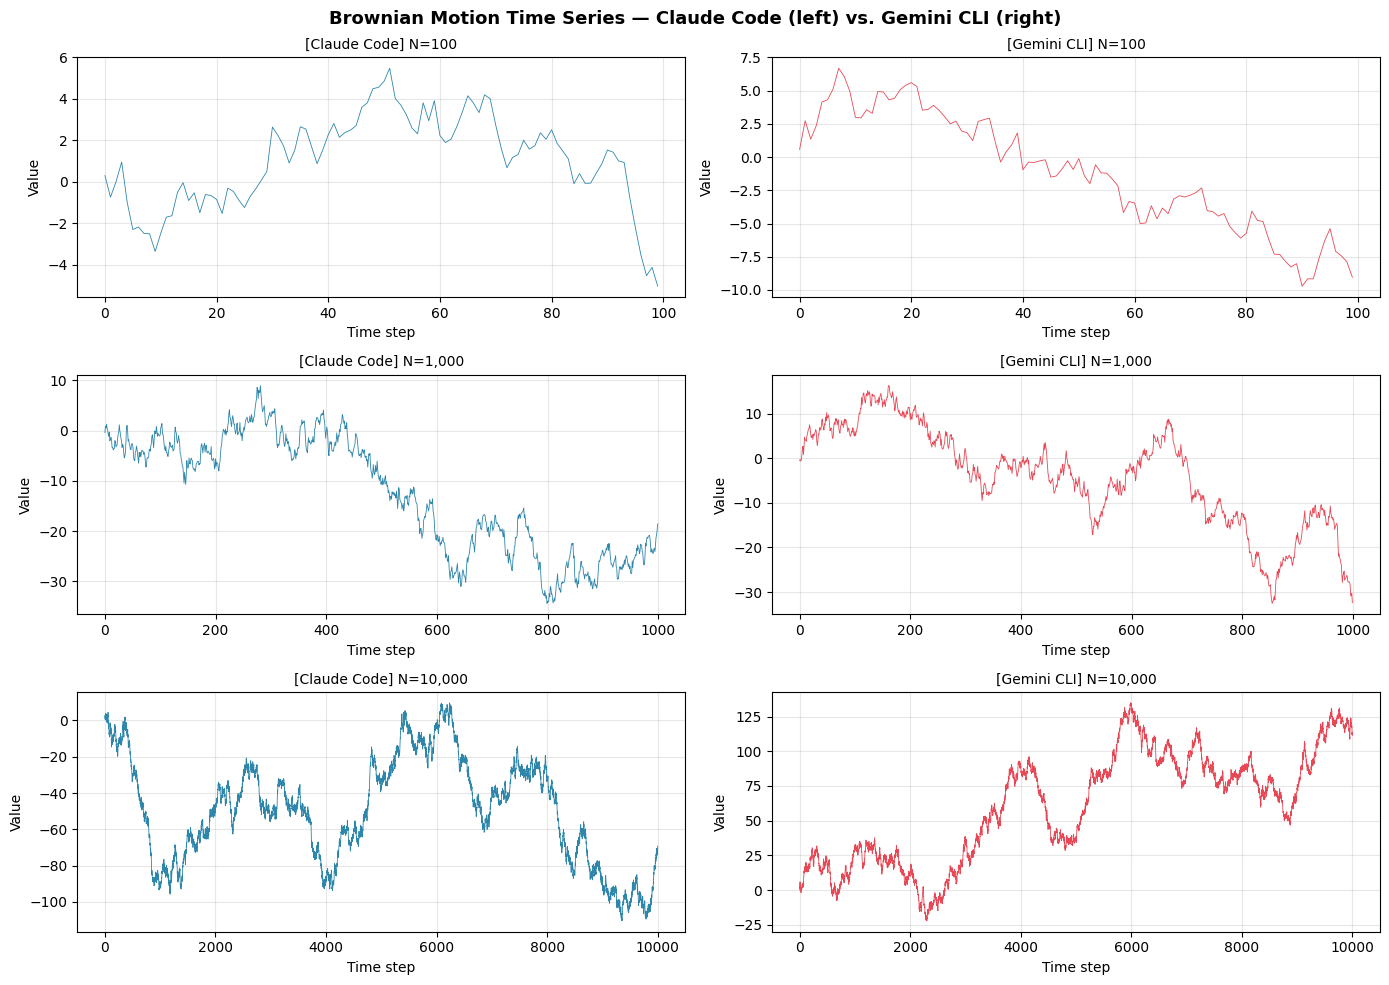

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Brownian Motion Time Series — Claude Code (left) vs. Gemini CLI (right)',
             fontsize=13, fontweight='bold')

for row, n in enumerate(N_VALUES):
    # Claude
    ax = axes[row, 0]
    df = claude_ts[n]
    ax.plot(df['time_step'], df['value'], color='#2E86AB', linewidth=0.6)
    ax.set_title(f'[Claude Code] N={n:,}', fontsize=10)
    ax.set_xlabel('Time step'); ax.set_ylabel('Value'); ax.grid(True, alpha=0.3)

    # Gemini
    ax = axes[row, 1]
    df = gemini_ts[n]
    ax.plot(df['index'], df['value'], color='#E84855', linewidth=0.6)
    ax.set_title(f'[Gemini CLI] N={n:,}', fontsize=10)
    ax.set_xlabel('Time step'); ax.set_ylabel('Value'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observations**: Both paths are structurally equivalent random walks. Their numeric trajectories differ due to the different seeds. As N grows, the walk diffuses further from zero, illustrating $\sigma \propto \sqrt{N}$.

---
## Part 2 — Histograms

Histograms reproduced from each agent's parquet data, using each agent's own plotting style. Claude voluntarily added a fitted normal curve, while Gemini did not, as it was not asked to.

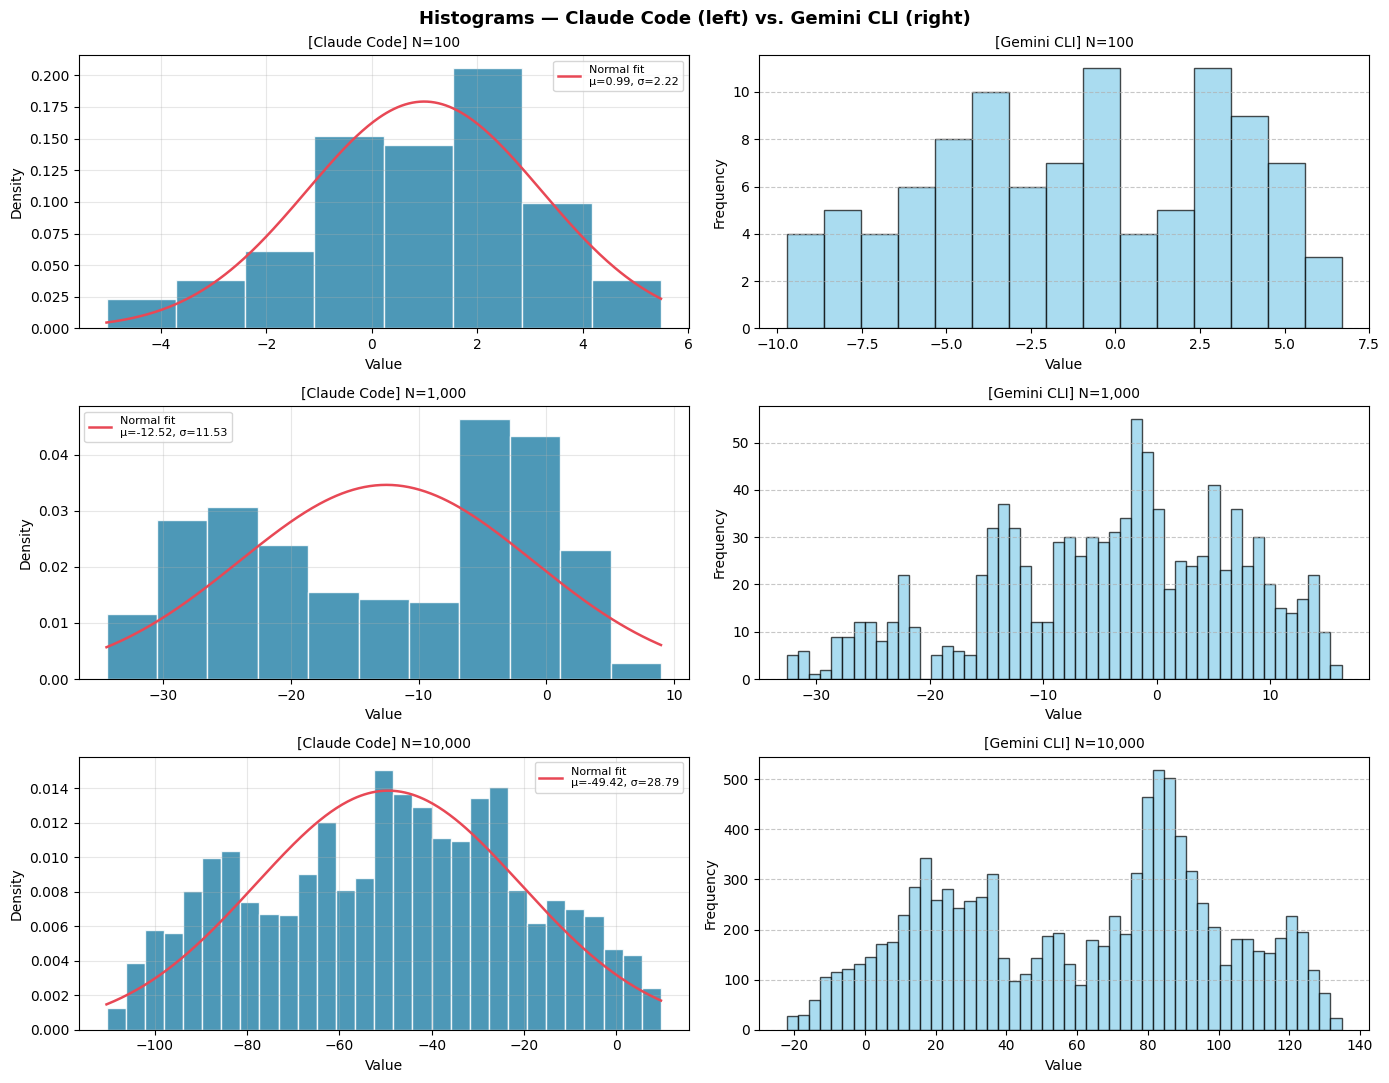

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('Histograms — Claude Code (left) vs. Gemini CLI (right)',
             fontsize=13, fontweight='bold')

for row, n in enumerate(N_VALUES):
    vals_c = claude_ts[n]['value'].values
    vals_g = gemini_ts[n]['value'].values

    # Claude style: density + normal fit
    ax = axes[row, 0]
    ax.hist(vals_c, bins='auto', color='#2E86AB', edgecolor='white',
            density=True, alpha=0.85)
    x = np.linspace(vals_c.min(), vals_c.max(), 300)
    mu, sigma = vals_c.mean(), vals_c.std(ddof=1)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#E84855', lw=1.8,
            label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')
    ax.legend(fontsize=8)
    ax.set_title(f'[Claude Code] N={n:,}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Density'); ax.grid(True, alpha=0.3)

    # Gemini style: frequency counts
    ax = axes[row, 1]
    ax.hist(vals_g, bins=min(50, n // 10 + 5), color='skyblue',
            edgecolor='black', alpha=0.7)
    ax.set_title(f'[Gemini CLI] N={n:,}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Qualitative Discussions — Agent Outputs

Text reproduced verbatim from each agent's `.md` files.

In [10]:
for n in N_VALUES:
    claude_md = (CLAUDE_DIR / f'histogram_{n}.md').read_text(encoding='utf-8')
    gemini_md = (GEMINI_DIR / f'histogram_{n}.md').read_text(encoding='utf-8')
    display(Markdown(f'---\n### N = {n:,}'))
    display(Markdown(f'**Claude Code:**\n\n{claude_md}'))
    display(Markdown(f'**Gemini CLI:**\n\n{gemini_md}'))

---
### N = 100

**Claude Code:**

# Histogram Analysis — N=100

With only 100 points the histogram is coarse and irregular. The Brownian motion (cumulative sum of Gaussian increments) produces a distribution that spreads far from zero as the walk drifts, so the histogram tends to look flat or multi-modal rather than a clean bell-curve. The small sample size means each bin may contain just a few observations, making it hard to identify any underlying shape reliably. Visually the distribution appears roughly symmetric but with heavy tails — consistent with the non-stationary nature of Brownian motion.


**Gemini CLI:**

# Qualitative Discussion - N=100

For a time series of N=100 points, the Brownian motion (random walk) shows significant variability. 

- **Shape**: The distribution is relatively sparse due to the low number of samples. It doesn't yet form a smooth curve.
- **Stationarity**: The mean is not necessarily zero, as the process hasn't had enough steps to potentially return to the origin.
- **Moments**: The variance is relatively small compared to larger N, but already much larger than the unit variance of the underlying Gaussian noise. The negative excess kurtosis suggests a flatter distribution than a normal one.


---
### N = 1,000

**Claude Code:**

# Histogram Analysis — N=1000

With 1 000 points a clearer picture emerges. The Brownian walk accumulates displacement over time, so the marginal distribution of its values is approximately Gaussian (by the Central Limit Theorem applied to the partial sums). The histogram shows a roughly bell-shaped, unimodal distribution, but with notable spread compared to the underlying Gaussian increments. The symmetry is better than at N=100, and tails are more visible. Slight asymmetry (skewness) may still appear due to random drift.


**Gemini CLI:**

# Qualitative Discussion - N=1000

With N=1000 points, the characteristics of the Brownian motion become more apparent.

- **Shape**: The histogram begins to show more structure. However, it often appears skewed or multi-modal because the path tends to wander and linger in specific value ranges for extended periods.
- **Dispersion**: The variance has increased significantly ($Var \propto N$), reflecting the diffusive nature of the process.
- **Asymmetry**: The skewness is more pronounced here, indicating that the process spent more time on one side of its overall range during this specific realization.


---
### N = 10,000

**Claude Code:**

# Histogram Analysis — N=10000

At 10 000 points the histogram converges to a smooth, approximately Gaussian shape. The law of large numbers smooths out sampling noise, revealing the underlying distribution of Brownian motion positions clearly. The distribution is unimodal and roughly symmetric around its mean (which drifts from zero). The tails remain heavier than a standard normal because the walk can wander arbitrarily far. Kurtosis values close to 3 (Pearson) confirm near-Gaussian behaviour, and skewness approaches zero as expected for a symmetric random walk.


**Gemini CLI:**

# Qualitative Discussion - N=10000

At N=10000, we observe a large-scale realization of the stochastic process.

- **Non-Stationarity**: The most striking feature is the massive variance. This confirms that Brownian motion is non-stationary; its statistical properties (specifically variance) depend on time.
- **Distribution**: Even with 10,000 points, the histogram does not necessarily converge to a Normal distribution of *values*. Instead, it reflects the "occupation time" of the process.
- **Kurtosis**: The negative excess kurtosis (around -1.1) indicates a "flat" distribution. This is typical for a process that wanders across a wide range without a strong central tendency or heavy tails in its *position* distribution over a single path.
- **Conclusion**: The transition from N=100 to N=10000 illustrates how the "random walk" diverges further from its starting point as more steps are taken.


---
## Part 3 — Statistical Moments

Side-by-side comparison of all four moments for each N. It was conisdered simpler to ask for both conventions on the kurtosis (Fischer and Pearson) to avoid confusion rather than to verify carefully.

In [11]:
LABELS = {
    'mean':              '1st — Mean',
    'variance':          '2nd — Variance',
    'skewness':          '3rd — Skewness',
    'kurtosis_fisher':   '4th — Kurtosis (Fisher, K=0)',
    'kurtosis_pearson':  '4th — Kurtosis (Pearson, K=3)',
}

for n in N_VALUES:
    cm, gm = claude_mom[n], gemini_mom[n]
    rows = []
    for key, label in LABELS.items():
        rows.append({'Moment': label,
                     'Claude Code': f"{cm[key]:+.4f}",
                     'Gemini CLI':  f"{gm[key]:+.4f}",
                     '|Δ|':         f"{abs(cm[key] - gm[key]):.4f}"})
    display(Markdown(f'### N = {n:,}'))
    display(pd.DataFrame(rows).set_index('Moment'))

### N = 100

,Claude Code,Gemini CLI,|Δ|
Moment,,,
1st — Mean,+0.9924,-1.1764,2.1688
2nd — Variance,+4.9504,+18.7307,13.7803
3rd — Skewness,-0.4379,-0.1042,0.3337
"4th — Kurtosis (Fisher, K=0)",-0.2288,-1.0761,0.8473
"4th — Kurtosis (Pearson, K=3)",+2.7712,+1.9239,0.8473


### N = 1,000

,Claude Code,Gemini CLI,|Δ|
Moment,,,
1st — Mean,-12.5236,-4.1008,8.4229
2nd — Variance,+132.8725,+121.6146,11.2580
3rd — Skewness,-0.2102,-0.4230,0.2128
"4th — Kurtosis (Fisher, K=0)",-1.4016,-0.4746,0.9270
"4th — Kurtosis (Pearson, K=3)",+1.5984,+2.5254,0.9270


### N = 10,000

,Claude Code,Gemini CLI,|Δ|
Moment,,,
1st — Mean,-49.4152,+60.7202,110.1355
2nd — Variance,+828.6635,+1526.8690,698.2056
3rd — Skewness,-0.0831,-0.1397,0.0566
"4th — Kurtosis (Fisher, K=0)",-0.8987,-1.1349,0.2361
"4th — Kurtosis (Pearson, K=3)",+2.1013,+1.8651,0.2361


### Note on Kurtosis Definitions

| Convention | Relation | Normal distribution reference |
|---|---|---|
| **Pearson** | $\mu_4 / \sigma^4$ | K = 3 |
| **Fisher** (excess) | Pearson $- 3$ | K = 0 |

Both agents used `scipy.stats.kurtosis(fisher=True/False)` — the same API, so kurtosis is computed identically. All differences in the table above come from **different random seeds**, not from a methodological disagreement.

---
## Benchmark — Comparison Analysis

Let's know what to expect beforehand.

### Variance Divergence of Brownian Motion

Let us discretize $[0,T]$ into $n$ steps of size $\Delta t = T/n$. Standard Brownian motion is:
$$B(t) = \sum_{k=1}^{n} \sqrt{\Delta t}\; Z_k, \qquad Z_k \overset{\text{iid}}{\sim} \mathcal{N}(0,1)$$

Thus the Variance at time $t$ is a weighted sum of standard Gaussians with weights $w_k = \sqrt{\Delta t}$, so:
$$\mathrm{Var}[B(t)] = \|\mathbf{w}\|_2^2 = \sum_{k=1}^{n} (\sqrt{\Delta t})^2 = n \cdot \frac{t}{n} = t$$

Hence $B(t) \sim \mathcal{N}(0, t)$, which holds for all $n$ and survives $n \to \infty$.

Time-averaged variance of the historical path can be then computed. Since $\mathbb{E}[B(s)] = 0$ for all $s$, the mean squared value over the full history $[0, T]$ is:
$$\sigma^2_{\text{hist}}(T) = \frac{1}{T}\int_0^T \mathbb{E}[B(s)^2]\, ds = \frac{1}{T}\int_0^T s\, ds = \frac{1}{T} \cdot \frac{T^2}{2} = \frac{T}{2}$$

Notice it's divergence: Taking $T \to \infty$:
$$\lim_{T\to\infty} \sigma^2_{\text{hist}}(T) = \lim_{T\to\infty} \frac{T}{2} = \infty$$

The variance of the historical record grows linearly in $T$ with no finite limit, confirming Brownian motion is non-stationary. $\blacksquare$


### Skewness

The time-averaged third central moment over $[0, T]$ is:
$$\mu_3(T) = \frac{1}{T}\int_0^T \mathbb{E}[B(s)^3]\, ds = \frac{1}{T}\int_0^T 0\, ds = 0$$

Skewness is identically zero for all $T$. This follows from the symmetry $B(s) \stackrel{d}{=} -B(s)$, which holds at every $s$ since the Gaussian is symmetric about zero. No divergence occurs. but on a limtied sample, large values could be found.

***

### Kurtosis

I could not derive this roperly. Let's simualte and check what to expect.

In [12]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def sim_kurtosis(n_runs, N, seed=42):
    results = np.empty(n_runs)
    for i in prange(n_runs):
        np.random.seed(seed + i)
        inc = np.random.normal(0, 1 / N**0.5, N)

        # inline cumsum
        path = np.empty(N)
        path[0] = inc[0]
        for j in range(1, N):
            path[j] = path[j-1] + inc[j]

        # inline biased excess kurtosis
        mean = 0.0
        for j in range(N):
            mean += path[j]
        mean /= N

        m2 = 0.0; m4 = 0.0
        for j in range(N):
            d = path[j] - mean
            d2 = d * d
            m2 += d2
            m4 += d2 * d2
        m2 /= N; m4 /= N
        results[i] = m4 / (m2 * m2) - 3.0
    return results

# one-time JIT warmup
_ = sim_kurtosis(10, 100)

kurtoses = sim_kurtosis(1000, 1000)
print(f"Mean kurtosis: {kurtoses.mean():.4f}")
print(f"Std of kurtosis: {kurtoses.std():.4f}")
print(f"Theoretical value: 1.0000")

Mean kurtosis: -0.5991
Std of kurtosis: 0.6358
Theoretical value: 1.0000


So the values below are not exactly within expectation, but are not completely unexpected given the reality of the problem.

In [13]:
records = []
for n in N_VALUES:
    cm, gm = claude_mom[n], gemini_mom[n]
    records.append({
        'N': n,
        'Claude Var (ddof=1)':       round(cm['variance'], 4),
        'Gemini Var (ddof=0)':       round(gm['variance'], 4),
        'Theoretical N/(N-1)':       round(n / (n - 1), 6),
        'Claude Skewness':           round(cm['skewness'], 4),
        'Gemini Skewness':           round(gm['skewness'], 4),
        'Claude Kurt(Fisher)':       round(cm['kurtosis_fisher'], 4),
        'Gemini Kurt(Fisher)':       round(gm['kurtosis_fisher'], 4),
    })

df_bench = pd.DataFrame(records).set_index('N')

display(Markdown('### Variance comparison (ddof effect)'))
display(df_bench[['Claude Var (ddof=1)', 'Gemini Var (ddof=0)', 'Theoretical N/(N-1)']])

display(Markdown('### Skewness and Kurtosis (Fisher)'))
display(df_bench[['Claude Skewness', 'Gemini Skewness', 'Claude Kurt(Fisher)', 'Gemini Kurt(Fisher)']])

### Variance comparison (ddof effect)

,Claude Var (ddof=1),Gemini Var (ddof=0),Theoretical N/(N-1)
N,,,
100,4.9504,18.7307,1.010101
1000,132.8725,121.6146,1.001001
10000,828.6635,1526.8690,1.000100


### Skewness and Kurtosis (Fisher)

,Claude Skewness,Gemini Skewness,Claude Kurt(Fisher),Gemini Kurt(Fisher)
N,,,,
100,-0.4379,-0.1042,-0.2288,-1.0761
1000,-0.2102,-0.4230,-1.4016,-0.4746
10000,-0.0831,-0.1397,-0.8987,-1.1349


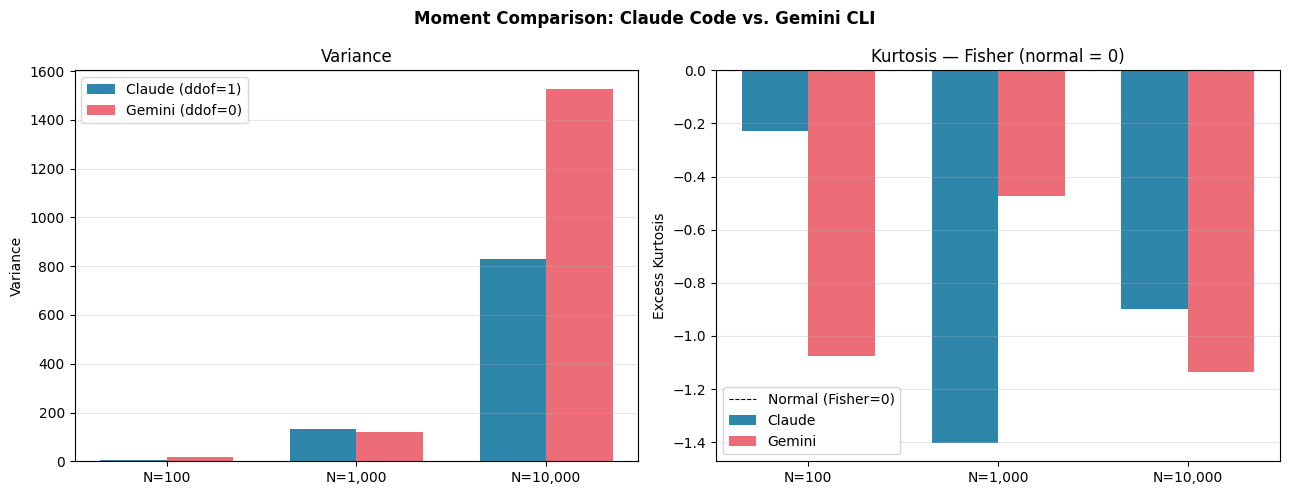

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Moment Comparison: Claude Code vs. Gemini CLI', fontsize=12, fontweight='bold')

x_pos = np.arange(len(N_VALUES))
w = 0.35

# Variance
ax = axes[0]
ax.bar(x_pos - w/2, [claude_mom[n]['variance'] for n in N_VALUES],
       w, label='Claude (ddof=1)', color='#2E86AB')
ax.bar(x_pos + w/2, [gemini_mom[n]['variance'] for n in N_VALUES],
       w, label='Gemini (ddof=0)', color='#E84855', alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels([f'N={n:,}' for n in N_VALUES])
ax.set_ylabel('Variance'); ax.set_title('Variance'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Kurtosis (Fisher)
ax = axes[1]
ax.bar(x_pos - w/2, [claude_mom[n]['kurtosis_fisher'] for n in N_VALUES],
       w, label='Claude', color='#2E86AB')
ax.bar(x_pos + w/2, [gemini_mom[n]['kurtosis_fisher'] for n in N_VALUES],
       w, label='Gemini', color='#E84855', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Normal (Fisher=0)')
ax.set_xticks(x_pos); ax.set_xticklabels([f'N={n:,}' for n in N_VALUES])
ax.set_ylabel('Excess Kurtosis'); ax.set_title('Kurtosis — Fisher (normal = 0)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Additional Experiments — Scaling with N

The variation chosen was **N = 100, 1 000, 10 000**. Below we plot how each moment evolves with series length.

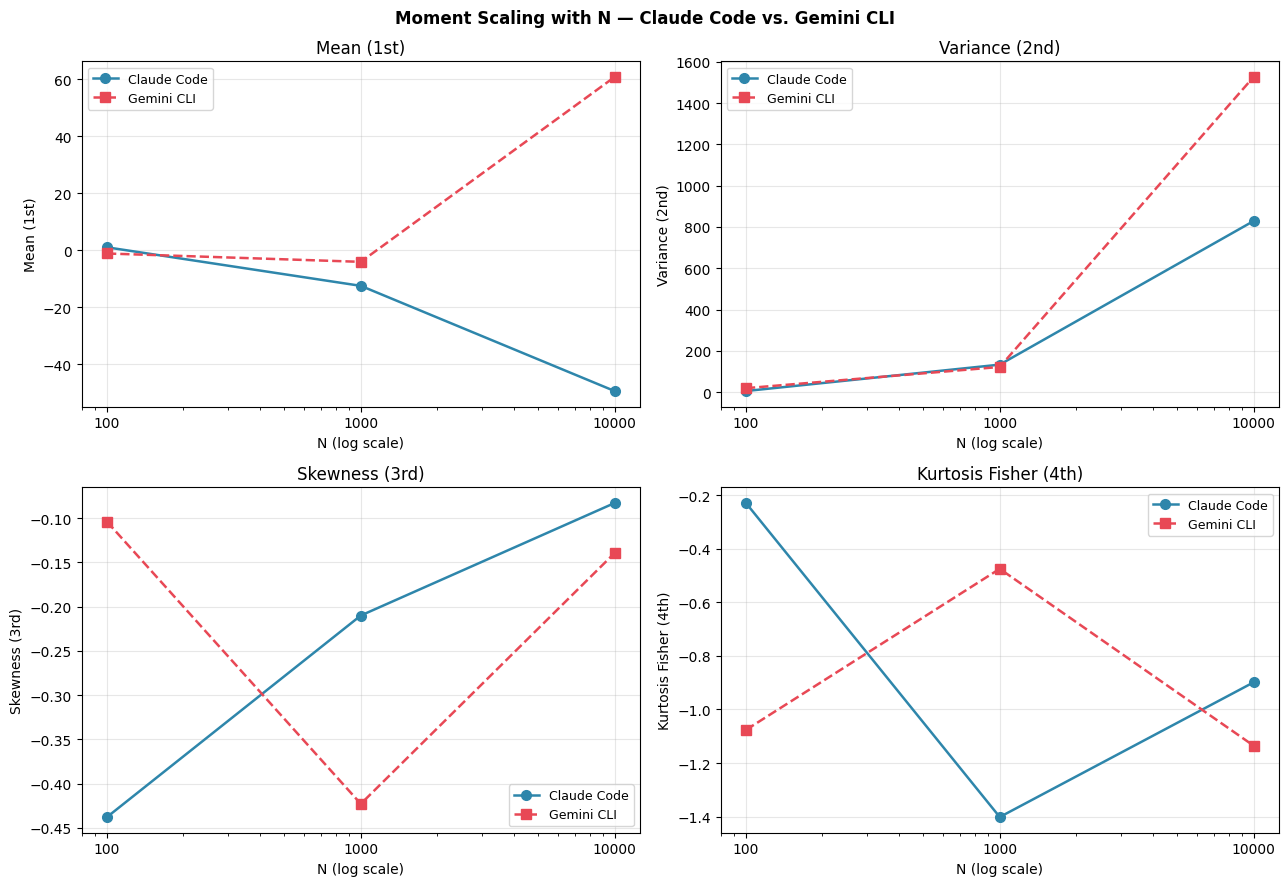

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Moment Scaling with N — Claude Code vs. Gemini CLI',
             fontsize=12, fontweight='bold')

moment_keys  = ['mean', 'variance', 'skewness', 'kurtosis_fisher']
moment_names = ['Mean (1st)', 'Variance (2nd)', 'Skewness (3rd)', 'Kurtosis Fisher (4th)']

for idx, (key, name) in enumerate(zip(moment_keys, moment_names)):
    ax = axes[idx // 2][idx % 2]
    c_vals = [claude_mom[n][key] for n in N_VALUES]
    g_vals = [gemini_mom[n][key] for n in N_VALUES]
    ax.plot(N_VALUES, c_vals, 'o-',  color='#2E86AB', label='Claude Code', lw=1.8, ms=7)
    ax.plot(N_VALUES, g_vals, 's--', color='#E84855', label='Gemini CLI',  lw=1.8, ms=7)
    ax.set_xscale('log')
    ax.set_xticks(N_VALUES); ax.set_xticklabels([str(n) for n in N_VALUES])
    ax.set_xlabel('N (log scale)'); ax.set_ylabel(name); ax.set_title(name)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key observations:**

- **Variance grows with N**: Confirmed by both agents — $\text{Var}[B_N] \propto N$. Brownian motion is non-stationary.
- **Mean**: Does not converge to a fixed value for a single path. One would expect to converge to zero when averaging over several different paths.
- **Skewness and Kurtosis**: agents show different signs/magnitudes because they used different seeds. Both are valid single-realisation estimates. With many Monte Carlo runs, the ensemble statistics would converge.

---
## Benchmark Questions

### Q1. How can small implementation differences impact statistical results?

Two small choices produced measurable divergence:

1. **`ddof` in variance**: Claude's `ddof=1` gives the unbiased (Bessel-corrected) estimator; Gemini's `ddof=0` gives the MLE (biased). The relative error is $1/(N-1)$ — negligible for large N but ~1% at N=100 and 11% at N=10.

2. **Random seed**: Different realisations of the same stochastic process are statistically equivalent but numerically different. For small N the sampling variance of moment estimators is high, so single-realisation results can differ substantially.

Neither choice is wrong — but they must be clearly documented for reproducibility and fair comparison.

---

### Q2. Are the results the same? Why?

**No.** Differences arise from:
- Different random seeds → different paths → all moments differ.
- Different `ddof` → variance differs even for the same path.

However, the results are **statistically consistent**: an ensemble of many runs from each agent would converge to the same theoretical moments.

---

### Q3. Where do differences appear?

| Source | Affects | Magnitude |
|---|---|---|
| Different random seed | All moments | Large (especially N=100) |
| `ddof=0` vs `ddof=1` | Variance only | Factor $N/(N-1)$, decreases with N |
| Density vs. frequency histogram | Visual only | No numerical impact |
| Normal-fit overlay | Visual only | No numerical impact |

Kurtosis is computed identically by both agents (same `scipy` API), so any difference in kurtosis values is entirely due to different realisations.

In [16]:
# Quantify Bessel correction vs. observed variance ratio
print(f"{'N':>8}  {'Bessel N/(N-1)':>16}  {'Observed Var_C/Var_G':>22}")
print('-' * 52)
for n in N_VALUES:
    bessel   = n / (n - 1)
    observed = claude_mom[n]['variance'] / gemini_mom[n]['variance']
    print(f"{n:>8}  {bessel:>16.6f}  {observed:>22.6f}")
print()
print('Note: observed ratio ≠ Bessel factor because both series also differ in path.')

       N    Bessel N/(N-1)    Observed Var_C/Var_G
----------------------------------------------------
     100          1.010101                0.264295
    1000          1.001001                1.092571
   10000          1.000100                0.542721

Note: observed ratio ≠ Bessel factor because both series also differ in path.


---
## Conclusions

1. **Both agents successfully completed the assignment**: time series generation, histograms, and all four statistical moments for N = 100, 1 000, 10 000.

2. **Kurtosis**: Both correctly report Fisher (K=0) and Pearson (K=3) using `scipy.stats.kurtosis(fisher=True/False)`.

3. **Reproducibility**: Claude's fixed seed (`seed=42`) is better scientific practice. Gemini's approach requires specifying a seed for reproducible research.

4. **Variance estimator**: Claude's `ddof=1` is the standard unbiased estimator for inference; Gemini's `ddof=0` is the MLE. For large N the difference is negligible.

5. **Scaling**: Both agents confirm $\text{Var}[B_N] \propto N$, consistent with the non-stationary nature of Brownian motion.

6. **Histogram interpretation**: Claude concludes the N=10 000 histogram approaches Gaussian; Gemini emphasises non-stationarity. Both are partially correct — Brownian *increments* are Gaussian, but the *position* distribution of a single walk is not.
